#Machine Learning-Based Building Energy Performance Prediction and Explainable Analysis

##Overview
This project investigates the application of machine learning approaches for predicting building heating demand using energy efficiency data.

The objective is to analyze the relationship between building characteristics and energy performance and explore data-driven approaches for sustainable energy system analysis.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_excel("ENB2012_data.xlsx")
data.head()
data.shape
data.isnull().sum()
# comment about dataset: The dataset represents different building geometries and their corresponding heating and cooling
# energy requirements. The objective is to develop a data-driven model to predict energy demand and identify important
# design parameters.


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


Text(0, 0.5, 'Frequency')

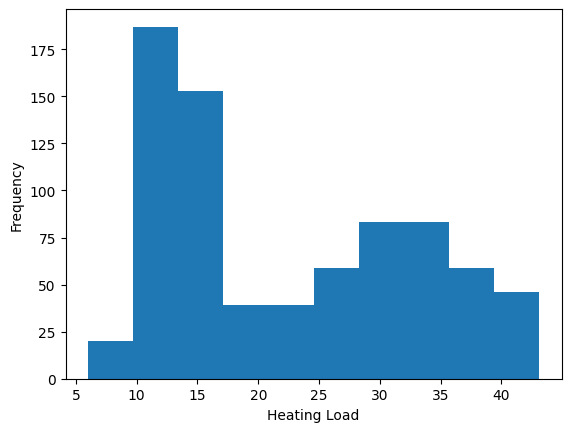

In [16]:
#Are most buildings low or high energy demand?
plt.hist(data["Y1"])
plt.xlabel("Heating Load")
plt.ylabel("Frequency")

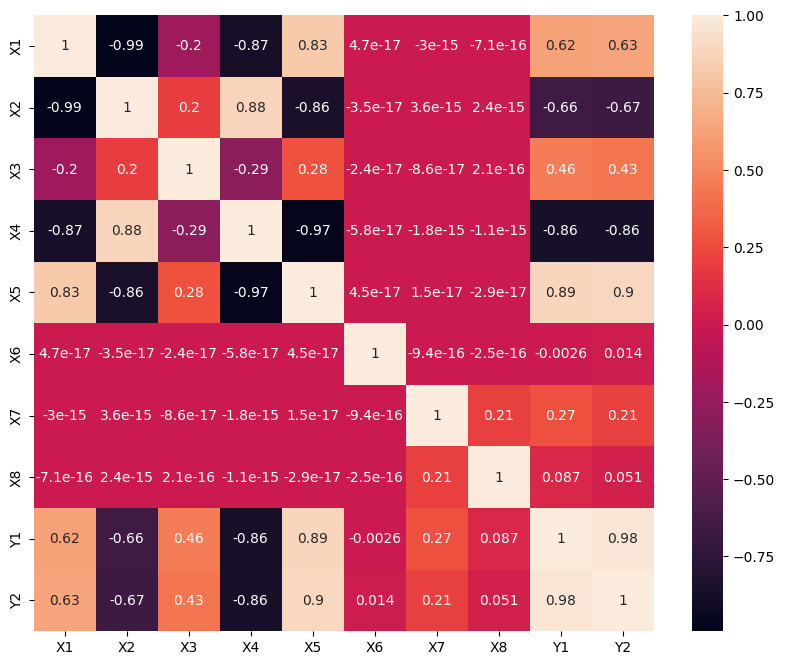

In [17]:
#Correlation Analysis between variables
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True)
plt.show()

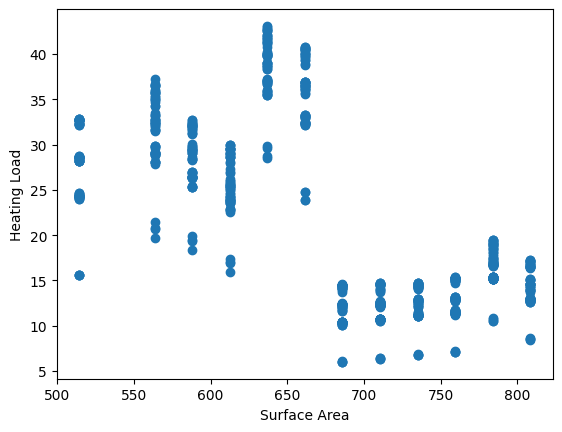

In [18]:
#Engineering Relationship Plot
#heating load vs Surface area
plt.scatter(data["X2"],data["Y1"])
plt.xlabel("Surface Area")
plt.ylabel("Heating Load")
plt.show()


In [19]:
#Separate Input and Output
X=data.iloc[:,0:8]
y=data["Y1"]
#Split Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [20]:
#Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_prediction=lr.predict(X_test)


In [21]:
#Model 2: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_prediction=rf.predict(X_test)


In [22]:
#Model 3: Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor()
gb.fit(X_train,y_train)
gb_prediction=gb.predict(X_test)


In [23]:
#Model 4: Neural Network
from sklearn.neural_network import MLPRegressor
ann=MLPRegressor(hidden_layer_sizes=(50,50),max_iter=1000)
ann.fit(X_train,y_train)


MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000)

In [24]:
#Evaluate Models
from sklearn.metrics import r2_score,mean_squared_error
print("Random Forest:",r2_score(y_test,rf_prediction))


Random Forest: 0.9976889803753333


In [25]:
from sklearn.metrics import r2_score,mean_squared_error
import pandas as pd

#create table
lr_prediction = lr.predict(X_test)
rf_prediction = rf.predict(X_test)
gb_prediction = gb.predict(X_test)
ann_prediction = ann.predict(X_test)

results = { "Model": [ "Linear Regression","Random Forest", "Gradient Boosting",
                      "ANN"],
  "R² Score": [
        r2_score(y_test, lr_prediction),
        r2_score(y_test, rf_prediction),
        r2_score(y_test, gb_prediction),
        r2_score(y_test, ann_prediction)
    ],

    "RMSE": [
        mean_squared_error(y_test, lr_prediction)**0.5,
        mean_squared_error(y_test, rf_prediction)**0.5,
        mean_squared_error(y_test, gb_prediction)**0.5,
        mean_squared_error(y_test, ann_prediction)**0.5
    ]
}

comparison_table = pd.DataFrame(results)
comparison_table

comparison_table.sort_values(by="R² Score", ascending=False)


,Model,R² Score,RMSE
1,Random Forest,0.997689,0.490798
2,Gradient Boosting,0.997448,0.515775
0,Linear Regression,0.912185,3.025427
3,ANN,0.876143,3.593037


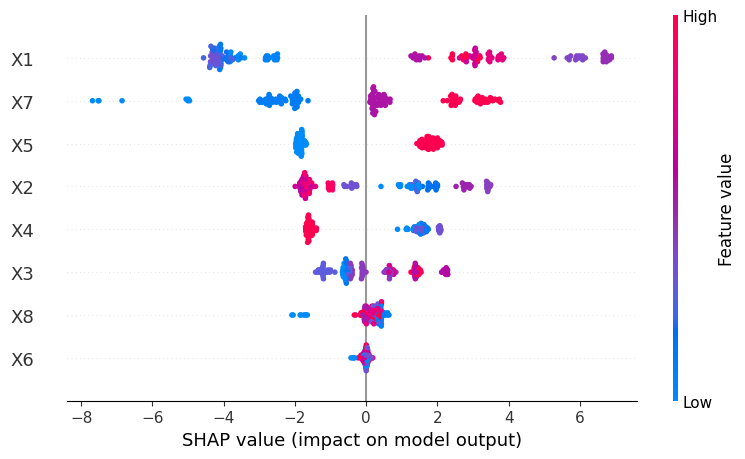

In [26]:
#Add Explainable AI (SHAP)
!pip install shap
import shap
explainer=shap.TreeExplainer(rf)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test)



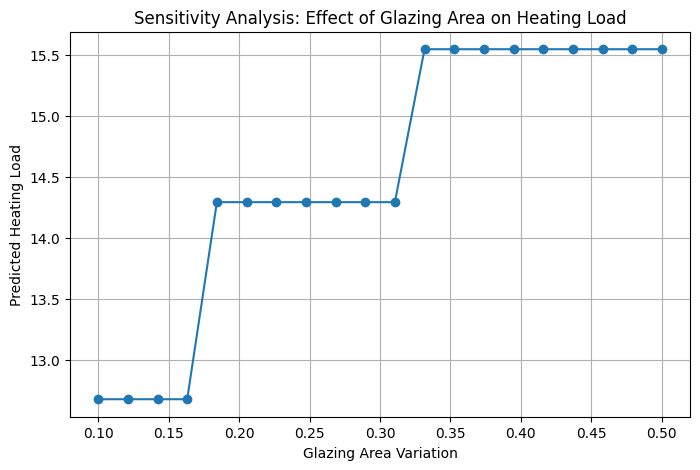

In [27]:
# Sensitivity Analysis: Effect of Glazing Variation on Heating Load
results = []
# Define range of glazing values to investigate
glazing_values = np.linspace(0.1, 0.5, 20)
for glazing in glazing_values:
    sample = X_test.iloc[0].copy()
    sample["X7"] = glazing
    sample_df = pd.DataFrame([sample])
    predicted_energy = rf.predict(sample_df)
    results.append(predicted_energy[0])

plt.figure(figsize=(8,5))
plt.plot(glazing_values, results, marker='o')
plt.xlabel("Glazing Area Variation")
plt.ylabel("Predicted Heating Load")
plt.title("Sensitivity Analysis: Effect of Glazing Area on Heating Load")
plt.grid(True)
plt.show()


## Interpretation

The sensitivity analysis demonstrates how changes in glazing area influence the predicted heating demand.

This analysis provides an initial understanding of parameter influence and can support future studies involving multi-parameter optimization approaches for energy-efficient building design.

Future work may incorporate optimization algorithms to identify optimal combinations of building parameters that minimize energy demand while satisfying engineering constraints.

##Future Research Direction

Future work will focus on integrating physics-based engineering knowledge with data-driven models for sustainable energy systems. Hybrid modeling and optimization approaches could be explored to improve prediction accuracy and support intelligent engineering decision-making.